# Spike firing sequences

First pass attempt at looking at sequences of firing 

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/scratch/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659']


In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])

## Let's load the data

In [5]:
# neural data
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay)


#### plot spikes

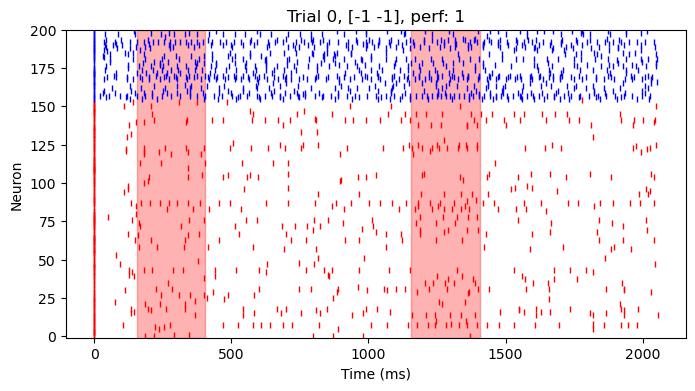

In [60]:
# plot a single trial (with function)

importlib.reload(sn)
importlib.reload(ld)

trial_id = 0
trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]

sn.plot_trial_raster(trial_df, condn_phrase, condn_num)

In [7]:
trial_df.head()

,cell_id,trial_id,cell_type,spk_times,model_name,delay150
0,0,0,exc,"[0.0, 3710.0, 4404.0, 15955.0, 17421.0, 19622....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,
1,1,0,exc,"[0.0, 6821.0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,
2,2,0,inh,"[1304.0, 3437.0, 5146.0, 6980.0, 7811.0, 9111....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,
3,3,0,exc,"[1, 0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,
4,4,0,exc,[0.0],Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,


In [15]:
first_spk_time = np.zeros(len(trial_df))
for i, row in trial_df.iterrows():
    if len(row['spk_times']) == 0:
        first_spk_time[i] = np.nan
    elif len(row['spk_times']) == 1: # if there's only one spike, use that
        first_spk_time[i] = row['spk_times'][0]
    else: # get first non-zero entry, or zero if that's the only entry
        first_spk_time[i] = [row['spk_times'][0] if row['spk_times'][0] != 0 else row['spk_times'][1]][0]
        

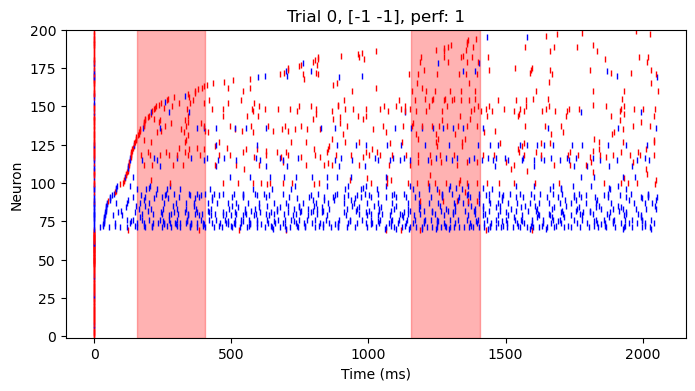

In [22]:
# sort by first spike time
importlib.reload(sn)
sort = np.argsort(first_spk_time)
sn.plot_trial_raster(trial_df, condn_phrase, condn_num, sort=sort)

In [61]:
# sort by first spike time after stim1 starts
times_spk, _, _ = ld.get_times_dict('spk',condn_phrase, condn_num)
stim1_on = times_spk['stim1_on']

stim1_first_spk_time = np.zeros(len(trial_df))
for i, row in trial_df.iterrows():
    if len(row['spk_times']) == 0:
        stim1_first_spk_time[i] = np.nan
    elif len(row['spk_times']) == 1: # if there's only one spike, use that
        stim1_first_spk_time[i] = row['spk_times'][0]
    else: # get first non-zero entry, or zero if that's the only entry
        first_idx = np.where(row['spk_times'] > stim1_on)[0]
        if len(first_idx) == 0:
            stim1_first_spk_time[i] = [row['spk_times'][0] if row['spk_times'][0] != 0 else row['spk_times'][1]][0]
        else:
            stim1_first_spk_time[i] = row['spk_times'][first_idx[0]]

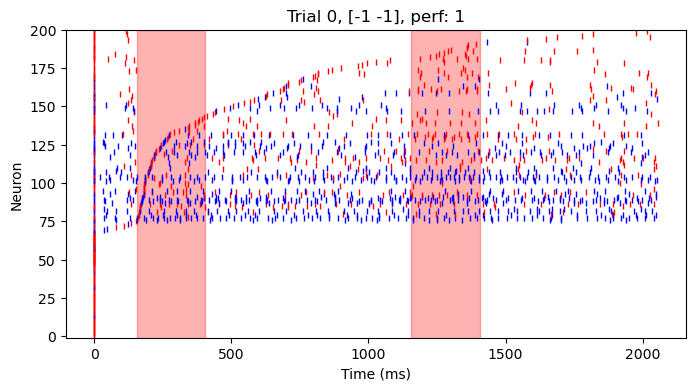

In [49]:
# sort by first spike time
importlib.reload(sn)
sort = np.argsort(stim1_first_spk_time)
sn.plot_trial_raster(trial_df, condn_phrase, condn_num, sort=sort)

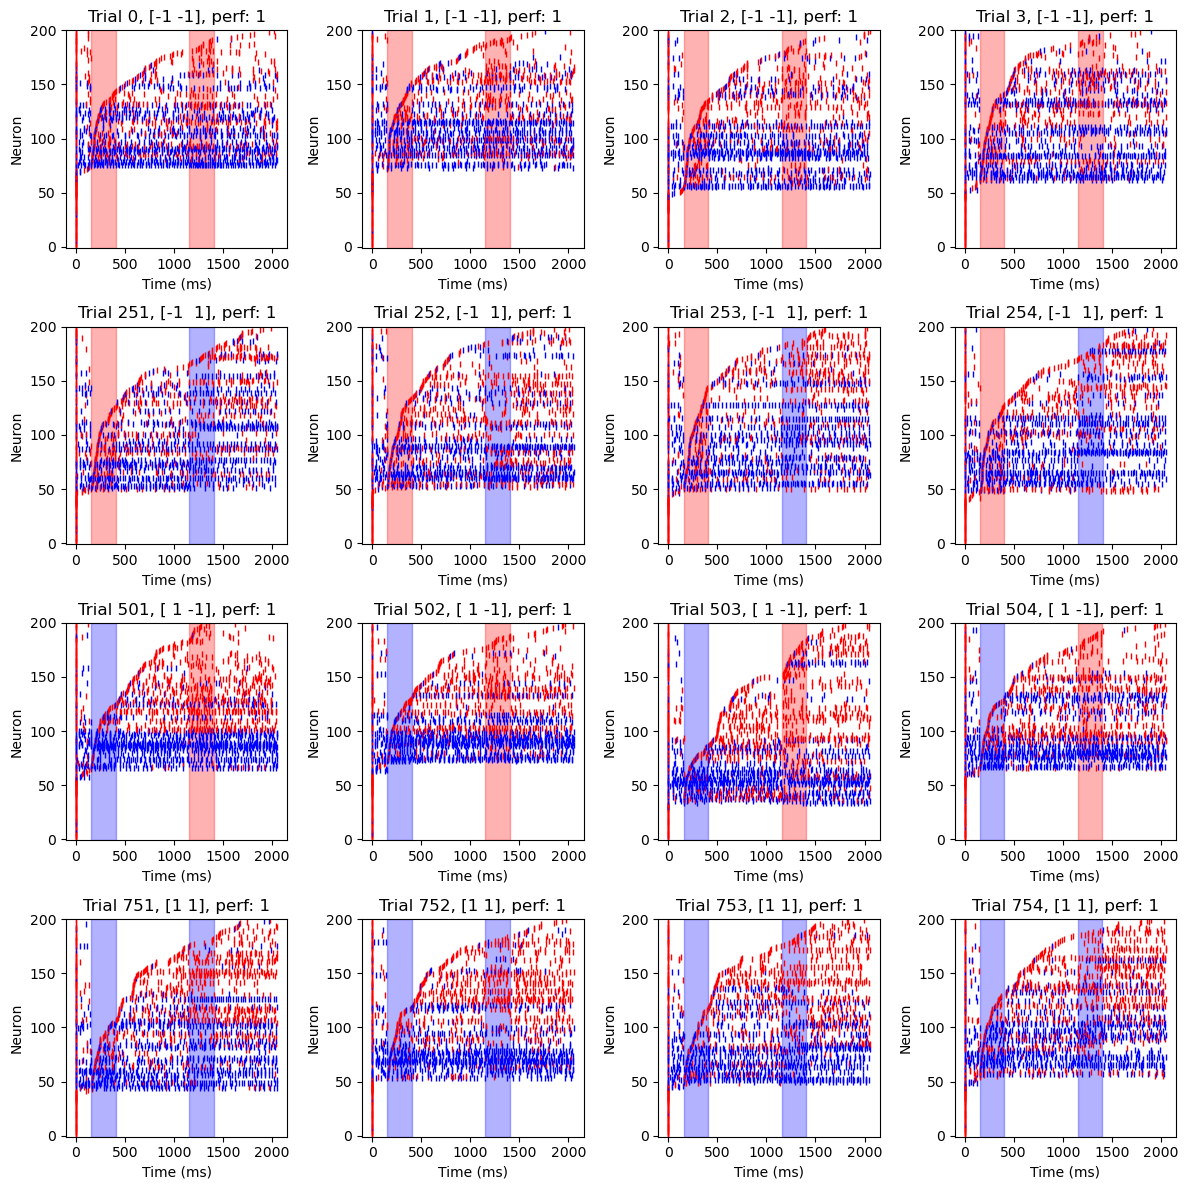

In [ ]:
# plot 16 random trials, sorting each trial

importlib.reload(sn)

trial_ids = [0, 1, 2, 3, 251, 252, 253, 254, 501, 502, 503, 504, 751, 752, 753, 754]
fig, ax = plt.subplots(4, 4, figsize=(12, 12))

for i, trial_id in enumerate(trial_ids):
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]
    stim1_first_spk_time = np.zeros(len(trial_df))
    for j, (_, row) in enumerate(trial_df.iterrows()):
        if len(row['spk_times']) == 0:
            stim1_first_spk_time[j] = np.nan
        elif len(row['spk_times']) == 1: # if there's only one spike, use that
            stim1_first_spk_time[j] = row['spk_times'][0]
        else: # get first non-zero entry, or zero if that's the only entry
            first_idx = np.where(row['spk_times'] >= stim1_on)[0]
            if len(first_idx) == 0:
                stim1_first_spk_time[j] = [row['spk_times'][0] if row['spk_times'][0] != 0 else row['spk_times'][1]][0]
            else:
                stim1_first_spk_time[j] = row['spk_times'][first_idx[0]]
    sort = np.argsort(stim1_first_spk_time)
    
    ax_i = np.unravel_index(i, (4, 4))
    sn.plot_trial_raster(trial_df, condn_phrase, condn_num, sort=sort, ax=ax[ax_i], title=f'Trial {trial_id}')
plt.tight_layout()

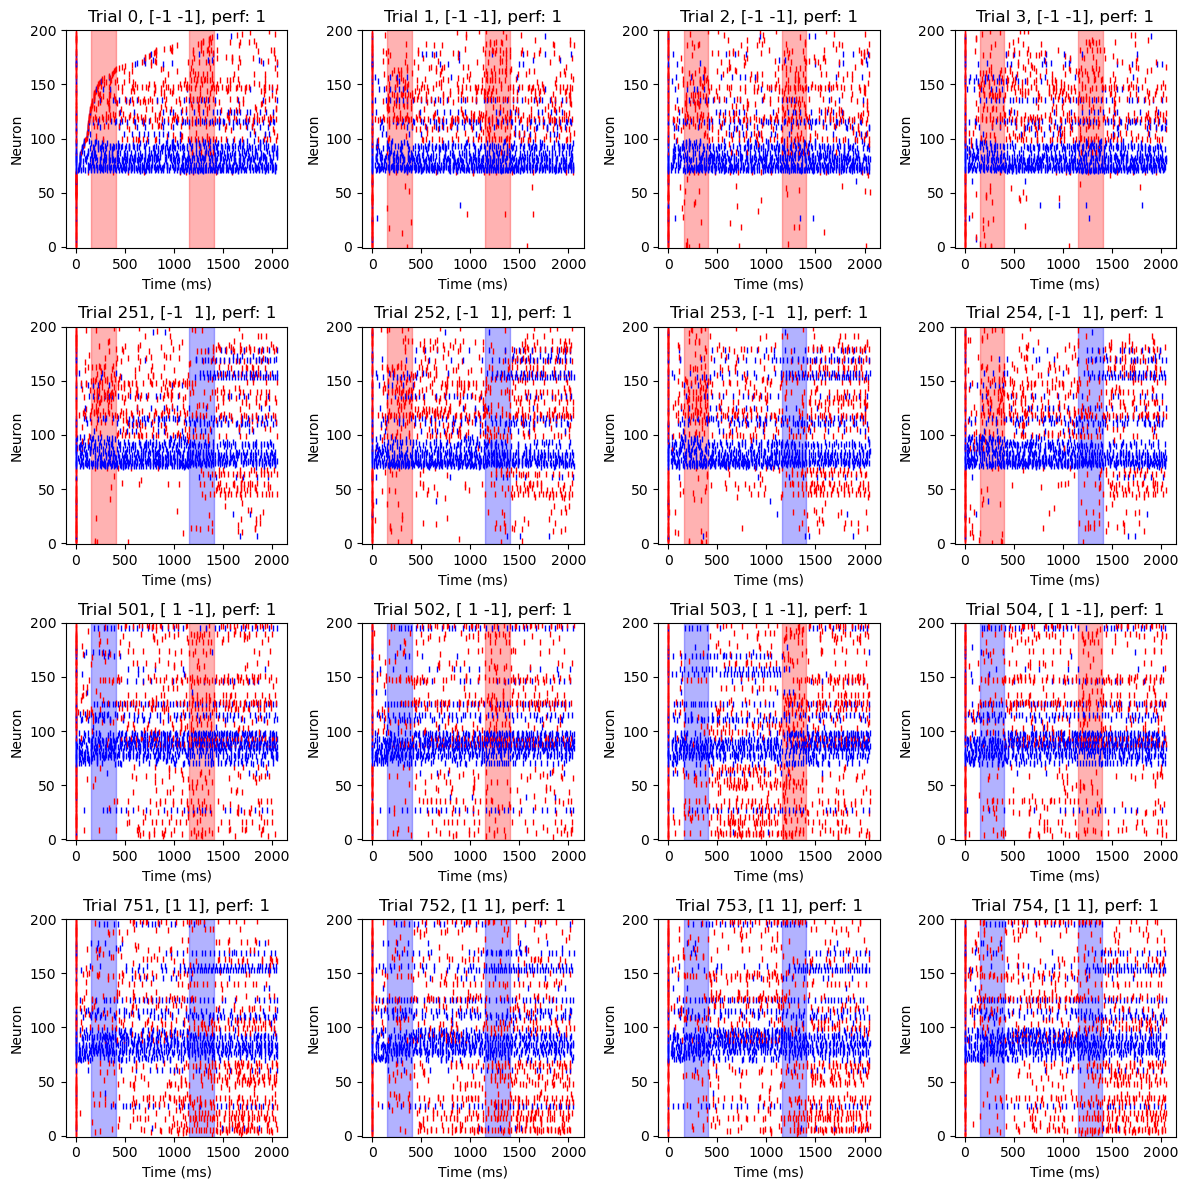

In [65]:
# plot 16 random trials, sort using the sort from the first trial (-1/-1)

importlib.reload(sn)

trial_ids = [0, 1, 2, 3, 251, 252, 253, 254, 501, 502, 503, 504, 751, 752, 753, 754]
fig, ax = plt.subplots(4, 4, figsize=(12, 12))


for i, trial_id in enumerate(trial_ids):
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]

    if i == 0:
        first_spk_time = np.zeros(len(trial_df))
        for j, row in trial_df.iterrows():
            if len(row['spk_times']) == 0:
                first_spk_time[j] = np.nan
            elif len(row['spk_times']) == 1: # if there's only one spike, use that
                first_spk_time[j] = row['spk_times'][0]
            else: # get first non-zero entry, or zero if that's the only entry
                first_spk_time[j] = [row['spk_times'][0] if row['spk_times'][0] != 0 else row['spk_times'][1]][0]
        sort = np.argsort(first_spk_time)
    
    ax_i = np.unravel_index(i, (4, 4))
    sn.plot_trial_raster(trial_df, condn_phrase, condn_num, sort=sort, ax=ax[ax_i], title=f'Trial {trial_id}')
plt.tight_layout()